## A first look at the data

In [4]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

In [5]:
df = pd.read_csv('_data.csv')

In [ ]:
#Backtest period
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df = df.loc['2022-01-01':'2024-01-01']

In [7]:
#transform data to returns
returns = df.pct_change().dropna()


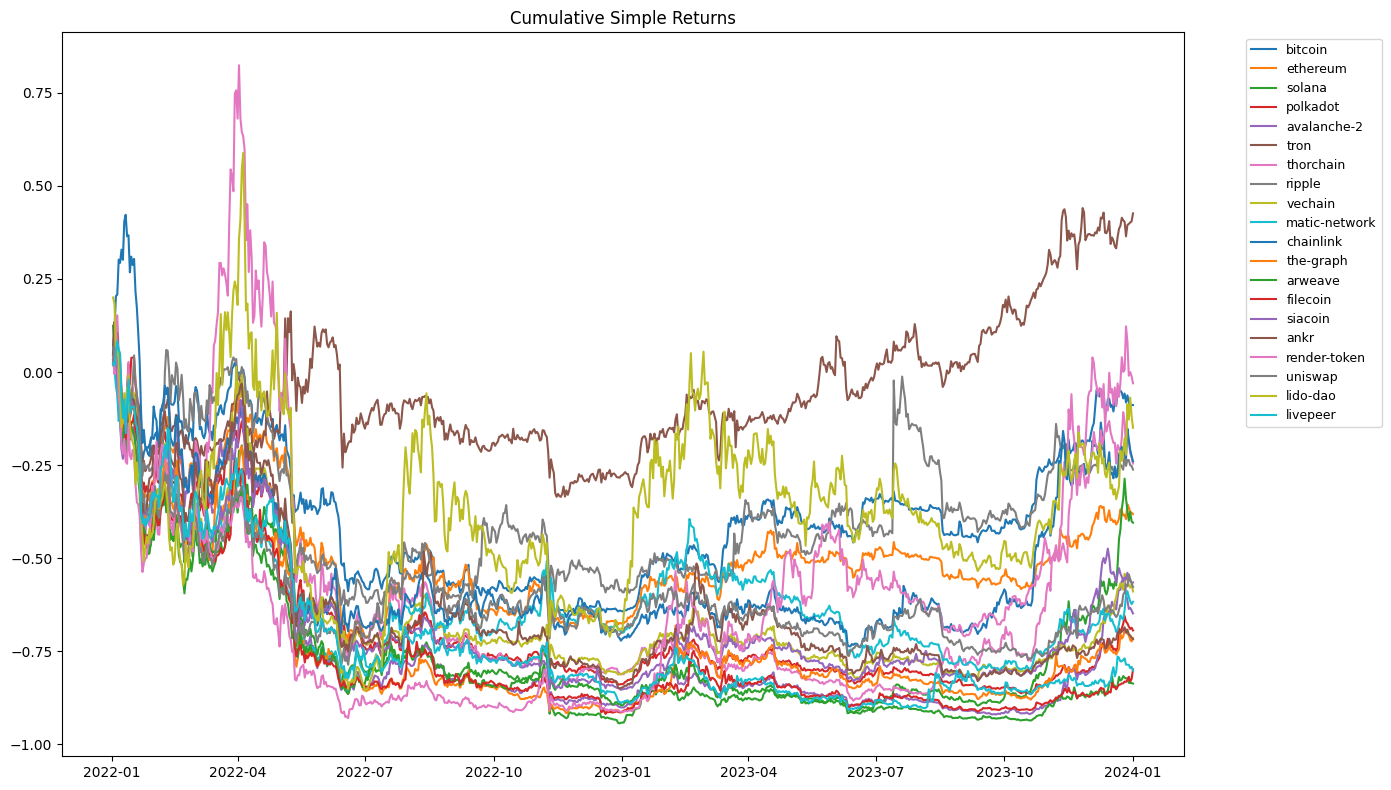

In [8]:
# plot cumulative simple returns
cum_returns = (1 + returns).cumprod() - 1 
cum_returns = cum_returns.dropna(how="all")

plt.figure(figsize=(14,8))
for col in cum_returns.columns:
    plt.plot(cum_returns.index, cum_returns[col], label=col, linewidth=1.5)
plt.title("Cumulative Simple Returns")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


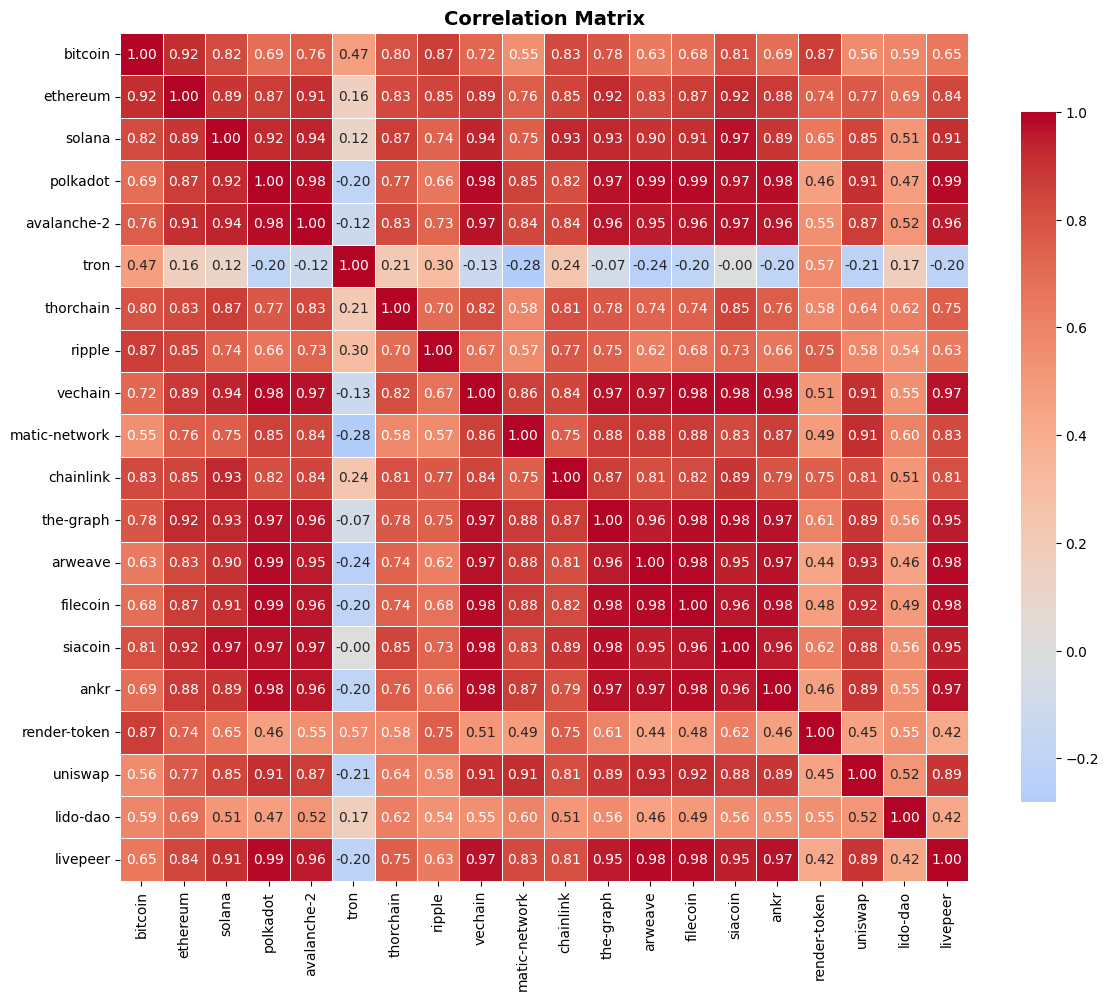

In [9]:
# Correlation matrix
correlation_matrix = df.corr()

#Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
